In [15]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from pyDOE import lhs

In [16]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

GPU: True


In [17]:
def random_fun(num):
    temp = torch.from_numpy(lb + (ub - lb) * lhs(2, num)).float()
    if use_gpu:
        temp = temp.cuda()
    return temp


def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data


In [18]:
class Net(nn.Module):
    def __init__(self, layers):
        super(Net, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a

In [19]:
class Model:
    def __init__(self, net, x_bc,
                 u_bc,
                 x_ic,
                 u_ic, 
                 x_ic_t,
                 u_ic_t,
                 x_f_loss_fun,
                 x_test, x_test_exact
                 ):


        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic
        
        # Klein-Gordon需要初始时刻的时间导数
        self.x_ic_t = x_ic_t
        self.u_ic_t = u_ic_t

        self.x_f_N = None
        self.x_f_M = None

        self.x_f_loss_fun = x_f_loss_fun

        self.x_test = x_test
        self.x_test_exact = x_test_exact

        self.x_test_estimate_collect = []


    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    # computer backward loss
    def epoch_loss(self):
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation = torch.mean(self.x_f_loss_fun(x_f, self.train_U) ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        # Neumann边界条件：计算空间导数损失
        x_bc_var = Variable(self.x_bc, requires_grad=True)
        u_bc_pred = self.train_U(x_bc_var)
        d_bc = torch.autograd.grad(u_bc_pred, x_bc_var, grad_outputs=torch.ones_like(u_bc_pred), create_graph=True)
        u_x_bc = d_bc[0][:, [1]]  # 空间导数 du/dx
        loss_bc = torch.mean((u_x_bc - self.u_bc) ** 2)

        # Klein-Gordon的初始时间导数条件
        x = Variable(self.x_ic_t, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)  # 时间导数
        loss_ic_t = torch.mean((u0_t - self.u_ic_t) ** 2)

        return loss_equation, loss_ic, loss_bc, loss_ic_t


    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation = torch.mean(self.x_f_loss_fun(x_f, self.train_U) ** 2)
        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        x_bc_var = Variable(self.x_bc, requires_grad=True)
        u_bc_pred = self.train_U(x_bc_var)
        d_bc = torch.autograd.grad(u_bc_pred, x_bc_var, grad_outputs=torch.ones_like(u_bc_pred), create_graph=True)
        u_x_bc = d_bc[0][:, [1]]
        loss_bc = torch.mean((u_x_bc - self.u_bc) ** 2)

        x = Variable(self.x_ic_t, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_ic_t = torch.mean((u0_t - self.u_ic_t) ** 2)

        loss = loss_equation + loss_ic + loss_bc + loss_ic_t  # 简化损失计算
        loss.backward()
        self.net.iter += 1
        print('Iter:', self.net.iter, 'Loss:', loss.item())
        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        exact = self.x_test_exact.cpu().detach().numpy()
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error

    def run_baseline(self):
        optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
        self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr, max_iter=lbgfs_iter)

        pbar = trange(adam_iter, ncols=100)
        for i in pbar:
            optimizer_adam.zero_grad()
            loss_e, loss_ic, loss_bc, loss_ic_t = self.epoch_loss()
            loss = loss_e + loss_ic + loss_bc + loss_ic_t  # 简化损失计算
            loss.backward()
            optimizer_adam.step()
            self.net.iter += 1
            pbar.set_postfix({'Iter': self.net.iter, 'Loss': '{0:.2e}'.format(loss.item())})

        print('Adam done!')
        self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
        print('LBGFS done!')

        error = self.evaluate()
        print('Test_L2error:', '{0:.2e}'.format(error))
    

    def run_AM(self):
        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr, max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc, loss_ic_t = self.epoch_loss()
                loss = loss_e + loss_ic + loss_bc + loss_ic_t  # 简化损失计算
                loss.backward()
                self.net.iter += 1
                optimizer_adam.step()
                pbar.set_postfix({'Iter': self.net.iter, 'Loss': '{0:.2e}'.format(loss.item())})

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            # 删除RAM相关代码，只保留WAM采样点更新逻辑
            x_init = random_fun(100000)
            x = Variable(x_init, requires_grad=True)
            u = self.train_U(x)
            dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
            grad_x1 = dx[:, [0]].squeeze()
            grad_x2 = dx[:, [1]].squeeze()
            dx = torch.sqrt(1 + grad_x2 ** 2).cpu().detach().numpy()
            err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
            p = (err_dx / sum(err_dx))
            p = p / np.sum(p)
            X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
            self.x_f_M = x_init[X_ids]
        


    def train(self):

        self.x_f_N = random_fun(N)
        self.x_f_M = random_fun(M)

        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AM()
        elapsed = time.time() - start_time
        print('Training time: %.2f' % elapsed)

In [20]:
# Klein-Gordon方程的精确解
def exact_u_func(x):
    """Klein-Gordon方程的精确解"""
    t = x[:, [0]]  # 时间
    x_coord = x[:, [1]]  # 空间坐标
    # u(x,t) = sqrt(alpha/gamma) * tanh(kappa(x - ct))
    # 其中 kappa = sqrt(alpha/(2(c^2-alpha^2)))
    kappa = np.sqrt(alpha / (2 * (c**2 - alpha**2)))
    return np.sqrt(alpha / gamma) * np.tanh(kappa * (x_coord - c * t))


def x_f_loss_fun(x, train_U):
    """Klein-Gordon方程的PDE损失函数"""
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    u = train_U(x)
    
    # 计算一阶导数
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, [0]]  # 时间导数
    u_x = d[0][:, [1]]  # 空间导数
    
    # 计算二阶导数
    u_tt = torch.autograd.grad(u_t, x, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, [0]]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, [1]]
    
    # Klein-Gordon方程: u_tt + beta*u_xx + alpha*u - gamma*u^3 = 0
    # 其中 beta = -alpha^2
    f = u_tt + beta * u_xx + alpha * u - gamma * u**3
    
    return f


In [21]:
def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    TT, XX = np.meshgrid(t, x)
    e = np.reshape(u_test_np, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'Exact $u(x,t)$', fontsize=20)
    plt.tight_layout()
    # plt.savefig('KG_exact.png')
    plt.show()

    e = np.reshape(predict_np, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    # plt.title(r'PINN $u(x,t)$', fontsize=20)
    plt.tight_layout()
    # plt.savefig('KG_pred_PINN.png')
    plt.show()


def draw_exact_points(points, N_points=None, show_exact=True):
    if show_exact:
        u_test_np = x_test_exact.cpu().detach().numpy()
        XX1, XX2 = np.meshgrid(t, x)
        e = np.reshape(u_test_np, (XX1.shape[0], XX1.shape[1]))
        plt.pcolor(XX1, XX2, e, shading='auto', cmap='YlGnBu')
        plt.colorbar()
        plt.title(r'Exact $u(x,t)$')
    if N_points is not None:
        adds = N_points.cpu().detach().numpy()
        plt.scatter(adds[:, [0]], adds[:, [1]], color='black', alpha=0.5, s=7)

    points = points.cpu().detach().numpy()
    plt.scatter(points[:, [0]], points[:, [1]], color= 'blue', alpha=0.5, s=7)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
    # plt.savefig('KG_xnm-PINN.png')
    plt.show()

In [22]:
if __name__ == '__main__':
    # Klein-Gordon方程的空间域: -10 < x < 10，时间域: 0 < t < 1
    t_min, t_max = 0.0, 12.0
    x_min, x_max = -10.0, 10.0
    
    lb = np.array([t_min, x_min])
    ub = np.array([t_max, x_max])

    layers = [2, 20, 20, 20, 20, 1]
    net = is_cuda(Net(layers))

    N = 500
    M = 500
    Nbc = 100
    Nic = 100

    adam_iter, lbgfs_iter = 5000, 50000
    adam_lr, lbgfs_lr = 0.001, 0.5

    model_type = 1  # 0:baseline  1:WAM

    AM_K = 1
    AM_count = 10

    # Klein-Gordon方程参数
    alpha = 0.1  # 可以调整这个值
    gamma = 1.0  # 可以调整这个值
    beta = -alpha**2  # β = -α²
    c = 0.3  # 波速，需要满足 c² > α²
    
    # 验证条件: α, γ, c² - α² > 0
    assert alpha > 0 and gamma > 0 and c**2 > alpha**2, "参数不满足Klein-Gordon方程的条件"

    # test data - 创建测试网格
    t = np.linspace(t_min, t_max, 100)  # 时间点
    x = np.linspace(x_min, x_max, 100)  # 空间点
    T, X = np.meshgrid(t, x)

    x_test_np = np.column_stack([T.ravel(), X.ravel()])
    solution = exact_u_func(x_test_np)
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    x_test_exact = is_cuda(torch.from_numpy(solution).float())

    # 初始条件 u(x,0) = sqrt(α/γ) tanh(κx)
    x_space = np.linspace(x_min, x_max, Nic)
    kappa = np.sqrt(alpha / (2 * (c**2 - alpha**2)))
    x_initial = np.column_stack([np.zeros(Nic), x_space])
    u_initial = np.sqrt(alpha / gamma) * np.tanh(kappa * x_space).reshape(-1, 1)
    
    # 初始时间导数条件 u_t(x,0) = -c*sqrt(α/γ)*κ*sech²(κx)
    x_initial_t = np.column_stack([np.zeros(Nic), x_space])
    sech_vals = 1.0 / np.cosh(kappa * x_space)
    u_initial_t = (-c * np.sqrt(alpha / gamma) * kappa * sech_vals**2).reshape(-1, 1)

    # 边界条件 - Neumann边界条件 (空间导数边界条件)
    # 根据精确解 u(x,t) = sqrt(α/γ) * tanh(κ(x - ct))
    # 其空间导数为: u_x(x,t) = sqrt(α/γ) * κ * sech²(κ(x - ct))
    t_boundary = np.random.uniform(0, t_max, Nbc)
    
    # 左边界 x = -10 的空间导数
    x_boundary_left = np.column_stack([t_boundary, np.full(Nbc, x_min)])
    sech_left = 1.0 / np.cosh(kappa * (x_min - c * t_boundary))
    u_x_boundary_left = (np.sqrt(alpha / gamma) * kappa * sech_left**2).reshape(-1, 1)
    
    # 右边界 x = 10 的空间导数
    x_boundary_right = np.column_stack([t_boundary, np.full(Nbc, x_max)])
    sech_right = 1.0 / np.cosh(kappa * (x_max - c * t_boundary))
    u_x_boundary_right = (np.sqrt(alpha / gamma) * kappa * sech_right**2).reshape(-1, 1)

    # 转换为torch张量
    x_ic = is_cuda(torch.from_numpy(x_initial).float())
    u_ic = is_cuda(torch.from_numpy(u_initial).float())
    
    x_ic_t = is_cuda(torch.from_numpy(x_initial_t).float())
    u_ic_t = is_cuda(torch.from_numpy(u_initial_t).float())
    
    # 边界条件现在是空间导数值 (Neumann条件)
    x_bc = is_cuda(torch.from_numpy(np.vstack([x_boundary_left, x_boundary_right])).float())
    u_bc = is_cuda(torch.from_numpy(np.vstack([u_x_boundary_left, u_x_boundary_right])).float())

    print(f"Klein-Gordon方程参数:")
    print(f"α = {alpha}, β = {beta}, γ = {gamma}, c = {c}")
    print(f"κ = {kappa}")
    print(f"空间域: [{x_min}, {x_max}], 时间域: [{t_min}, {t_max}]")
    print(f"条件验证: c² - α² = {c**2 - alpha**2} > 0: {c**2 > alpha**2}")

    model = Model(
        net=net,
        x_bc=x_bc,
        u_bc=u_bc,
        x_ic=x_ic,
        u_ic=u_ic,
        x_ic_t=x_ic_t,
        u_ic_t=u_ic_t,
        x_f_loss_fun=x_f_loss_fun,
        x_test=x_test,
        x_test_exact=x_test_exact,
    )

Klein-Gordon方程参数:
α = 0.1, β = -0.010000000000000002, γ = 1.0, c = 0.3
κ = 0.7905694150420949
空间域: [-10.0, 10.0], 时间域: [0.0, 12.0]
条件验证: c² - α² = 0.07999999999999999 > 0: True


In [23]:
model.train()
print(model.x_test_estimate_collect)

100%|█████████████████████████████████| 5000/5000 [01:34<00:00, 52.99it/s, Iter=5000, Loss=1.03e-06]


Adam done!
Iter: 5001 Loss: 1.0331405064789578e-06
Iter: 5002 Loss: 1.212347569889971e-06
Iter: 5003 Loss: 1.0770039580165758e-06
Iter: 5004 Loss: 1.0431758710183203e-06
Iter: 5005 Loss: 1.034717229231319e-06
Iter: 5006 Loss: 1.0325898074370343e-06
Iter: 5007 Loss: 1.0320666206098394e-06
LBGFS done!
change_counts 0 Test_L2error: 2.74e-02


100%|█████████████████████████████████| 5000/5000 [01:29<00:00, 55.93it/s, Iter=1e+4, Loss=2.33e-07]


Adam done!
Iter: 10008 Loss: 2.2696909240949026e-07
Iter: 10009 Loss: 3.4860292430494155e-07
Iter: 10010 Loss: 2.3706692786618078e-07
Iter: 10011 Loss: 2.0930467314883572e-07
Iter: 10012 Loss: 2.0270834966140683e-07
Iter: 10013 Loss: 2.01107013708679e-07
Iter: 10014 Loss: 2.007293460337678e-07
LBGFS done!
change_counts 1 Test_L2error: 1.76e-02


100%|████████████████████████████████| 5000/5000 [01:32<00:00, 54.18it/s, Iter=15014, Loss=5.93e-07]


...

Adam done!
Iter: 40064 Loss: 1.6611061255389359e-06
Iter: 40065 Loss: 3.480371742625721e-05
Iter: 40066 Loss: 8.823034477245528e-06
Iter: 40067 Loss: 2.2858541797177168e-06
Iter: 40068 Loss: 6.157404754958407e-07
Iter: 40069 Loss: 1.8746119678780815e-07
Iter: 40070 Loss: 7.638567467438406e-08
Iter: 40071 Loss: 4.677019305177055e-08
Iter: 40072 Loss: 3.826030692266613e-08
Iter: 40073 Loss: 3.5281203736303723e-08
Iter: 40074 Loss: 3.369033052535997e-08
Iter: 40075 Loss: 3.2205569766574627e-08
Iter: 40076 Loss: 3.015403748918288e-08
Iter: 40077 Loss: 2.6985876644403106e-08
Iter: 40078 Loss: 2.242787466855134e-08
Iter: 40079 Loss: 1.6910085776089545e-08
Iter: 40080 Loss: 1.170385477422542e-08
Iter: 40081 Loss: 9.541770928933602e-09
Iter: 40082 Loss: 8.613660007483759e-09
LBGFS done!
change_counts 7 Test_L2error: 6.98e-03


100%|████████████████████████████████| 5000/5000 [01:26<00:00, 57.74it/s, Iter=45082, Loss=1.68e-07]


Adam done!
Iter: 45083 Loss: 4.2686008328018943e-07
Iter: 45084 Loss: 1.310939660470467e-05
Iter: 45085 Loss: 3.2916436794039328e-06
Iter: 45086 Loss: 8.311095029966964e-07
Iter: 45087 Loss: 2.1721416487707756e-07
Iter: 45088 Loss: 6.345041470012802e-08
Iter: 45089 Loss: 2.4594561054414044e-08
Iter: 45090 Loss: 1.450882436415668e-08
Iter: 45091 Loss: 1.1658311649398456e-08
Iter: 45092 Loss: 1.06351656370407e-08
Iter: 45093 Loss: 1.0057286559117529e-08
LBGFS done!
change_counts 8 Test_L2error: 6.13e-03


100%|████████████████████████████████| 5000/5000 [01:36<00:00, 52.06it/s, Iter=50093, Loss=2.65e-06]


Adam done!
Iter: 50094 Loss: 3.0884511943440884e-06
Iter: 50095 Loss: 7.501833897549659e-05
Iter: 50096 Loss: 1.8827777239494026e-05
Iter: 50097 Loss: 4.697118583862903e-06
Iter: 50098 Loss: 1.185905261991138e-06
Iter: 50099 Loss: 3.098597289863392e-07
Iter: 50100 Loss: 9.052797622643993e-08
Iter: 50101 Loss: 3.5314577928602375e-08
Iter: 50102 Loss: 2.1200602162707582e-08
Iter: 50103 Loss: 1.7405596963726566e-08
Iter: 50104 Loss: 1.6199134478256383e-08
Iter: 50105 Loss: 1.562653650921675e-08
LBGFS done!
change_counts 9 Test_L2error: 6.12e-03
Training time: 924.49
[[0, '2.74e-02'], [1, '1.76e-02'], [2, '1.77e-02'], [3, '1.74e-02'], [4, '1.24e-02'], [5, '8.79e-03'], [6, '6.99e-03'], [7, '6.98e-03'], [8, '6.13e-03'], [9, '6.12e-03']]


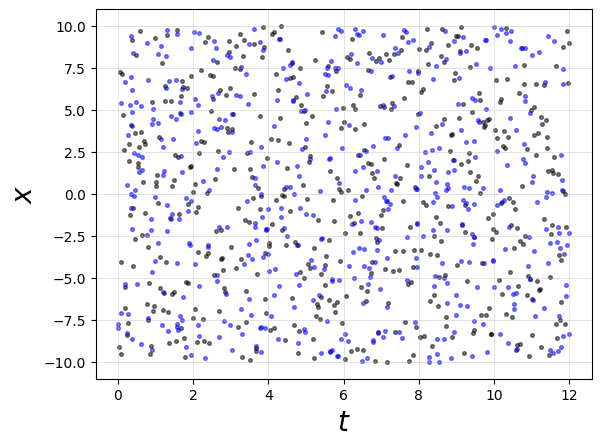

In [24]:
draw_exact_points(
    points=model.x_f_M,  # 动点M（蓝色散点）
    N_points=model.x_f_N,  # 不动点N（黑色x标记）
    show_exact=False  # 显示精确解作为背景
)